In [1]:
# =============================================================================
# STEP 1 — Data Ingestion & Cleaning
# Owner: Danish
# Dataset: PM2.5 Data of Five Chinese Cities (UCI ML Repository)
# Coverage: hourly observations, 2010-01-01 → 2015-12-31
# =============================================================================

import os
import pandas as pd
import numpy as np

# ── 1. File map ───────────────────────────────────────────────────────────────
# Place the five raw CSVs in the same directory as this notebook.
FILE_MAP = {
    "Beijing":   "BeijingPM20100101_20151231.csv",
    "Shanghai":  "ShanghaiPM20100101_20151231.csv",
    "Guangzhou": "GuangzhouPM20100101_20151231.csv",
    "Chengdu":   "ChengduPM20100101_20151231.csv",
    "Shenyang":  "ShenyangPM20100101_20151231.csv",
}

# Structural columns shared across all five datasets.
# 'precipitation' is included where available (absent in some cities → filled with 0).
CORE_COLS = ["city", "year", "month", "day", "hour", "season",
             "PM", "TEMP", "PRES", "HUMI", "DEWP", "Iws", "precipitation"]

# ── 2. Heating-regime definition ──────────────────────────────────────────────
# Treatment variable (causal block): binary indicator that equals 1 when
# the city is inside the government-mandated northern heating zone AND the
# calendar month falls within the active heating season (November–March).
#
# Northern cities (heating zone):  Beijing, Shenyang
# Southern cities (no mandate):    Shanghai, Guangzhou, Chengdu
#
# Source: China's district heating policy applies north of the Qinling–
# Huaihe line; the five cities straddle this boundary by design.

HEATING_CITIES  = {"Beijing", "Shenyang"}
HEATING_MONTHS  = {11, 12, 1, 2, 3}          # Nov–Mar (inclusive)

def engineer_heating_regime(df: pd.DataFrame) -> pd.DataFrame:
    """Add binary `heating_regime` column (treatment variable for causal block)."""
    df["heating_regime"] = (
        df["city"].isin(HEATING_CITIES) & df["month"].isin(HEATING_MONTHS)
    ).astype(int)
    return df

# ── 3. Ingestion loop ─────────────────────────────────────────────────────────

def load_city(city: str, filename: str) -> pd.DataFrame:
    """
    Read one city CSV and return a cleaned slice with unified columns.

    Key operations
    ──────────────
    • Detect and average across any PM_* monitoring-station columns → `PM`.
    • Retain only CORE_COLS; fill missing `precipitation` with 0.
    • Attach `city` label for panel identification.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Expected '{filename}' in the working directory. "
            "Download all five CSVs from https://archive-beta.ics.uci.edu/dataset/394"
        )

    df = pd.read_csv(filename, na_values=["NA", "NaN", " ", ""])
    df["city"] = city

    # Consolidate station-level PM columns (e.g. PM_US Post, PM_China_24h) into
    # one target by averaging across non-null readings for each hour.
    pm_cols = [c for c in df.columns if c.upper().startswith("PM_")]
    if not pm_cols:
        raise ValueError(f"No PM_* columns found in {filename}. Check column names.")
    df["PM"] = df[pm_cols].mean(axis=1)

    # Keep only the structural columns; tolerate missing optional ones.
    available = [c for c in CORE_COLS if c in df.columns]
    df = df[available].copy()

    # `precipitation` is absent in several city files — default to 0 (dry hour).
    if "precipitation" not in df.columns:
        df["precipitation"] = 0.0

    return df


print("── Ingesting city datasets ──────────────────────────────────────────────")
city_frames = []
for city, filename in FILE_MAP.items():
    frame = load_city(city, filename)
    print(f"  {city:10s}  {len(frame):>7,} raw rows  |  PM cols averaged")
    city_frames.append(frame)

df_raw = pd.concat(city_frames, ignore_index=True)
print(f"\n  Combined (raw):  {len(df_raw):>7,} rows × {df_raw.shape[1]} columns")

# ── 4. Temporal ordering ──────────────────────────────────────────────────────
# Sort the full panel chronologically within each city so that forward-fill
# operates strictly along the time axis (no future values bleed backward).

df_raw = (df_raw
          .sort_values(["city", "year", "month", "day", "hour"])
          .reset_index(drop=True))

# =============================================================================
# >>> CRITICAL FIX: CATCH SENSOR ANOMALIES BEFORE DROPPING MISSING VALUES <<<
# Convert hidden -9999.0 error codes to np.nan so your dropna pipeline works
# =============================================================================
print("── Processing data quality check: Purging -9999 sensor faults ──────────")
for col in ["HUMI", "DEWP"]:
    # Check how many anomalies exist before cleaning
    fault_count = (df_raw[col] == -9999.0).sum()
    print(f"  Found {fault_count:,} sensor error records (-9999.0) in column: {col}")
    
    # Replace with official NumPy NaN placeholders
    df_raw[col] = df_raw[col].replace(-9999.0, np.nan)
print("  Purge successful. Anomalies converted to NaN placeholders.\n")
# =============================================================================

# ── 5. Missing-value handling ─────────────────────────────────────────────────
# Three distinct strategies, motivated by different missingness mechanisms:
#
# (a) PM (target): equipment downtime causes gaps of a few consecutive hours.
#     Forward-fill within city propagates the last valid reading forward.
#
# (b) Weather features (TEMP, PRES, HUMI, DEWP, Iws): sporadic sensor faults.
#     Rows where any core weather feature remains missing are dropped entirely.
#
# (c) Precipitation (input): absent in some cities entirely or contains sporadic
#     missing values. Missing rows represent unrecorded periods, which are safely
#     imputed to 0.0 (assuming a dry hour) to avoid losing valuable panel rows.

WEATHER_FEATURES = ["TEMP", "PRES", "HUMI", "DEWP", "Iws"]

# (a) Forward-fill PM within each city's timeline
df_raw["PM"] = df_raw.groupby("city")["PM"].ffill()

# (b) NEW: Impute missing precipitation values to 0.0 before filtering rows
print("── Processing data quality check: Imputing missing precipitation values ──")
precip_nulls_before = df_raw["precipitation"].isna().sum()

# Capture per-city breakdown BEFORE fillna overwrites the NaNs (used in Step 1b diagnostic)
precip_nulls_by_city = df_raw.groupby("city")["precipitation"].apply(lambda g: g.isna().sum())

df_raw["precipitation"] = df_raw["precipitation"].fillna(0.0)
print(f"  Filled {precip_nulls_before:,} missing precipitation records with 0.0 (dry hours)")

# (c) Drop rows where any weather feature or PM is still null
n_before_drop = len(df_raw)
df_clean = df_raw.dropna(subset=["PM"] + WEATHER_FEATURES).reset_index(drop=True)
n_dropped = n_before_drop - len(df_clean)
print(f"  Rows dropped (null weather): {n_dropped:,}")
print(f"  Rows retained (clean panel): {len(df_clean):,}")

# ── 6. Treatment variable engineering ────────────────────────────────────────
df_clean = engineer_heating_regime(df_clean)

regime_counts = df_clean.groupby("city")["heating_regime"].sum()
print(f"\n── heating_regime summary (treated hours per city) ─────────────────────")
print(regime_counts.to_string())

# ── 7. Data-type enforcement ──────────────────────────────────────────────────
# Categorical city saves memory and speeds groupby operations downstream.
df_clean["city"]    = df_clean["city"].astype("category")
df_clean["season"]  = df_clean["season"].astype("category")

# Ensure temporal integers are native int (not float from merge artefacts)
for col in ["year", "month", "day", "hour"]:
    df_clean[col] = df_clean[col].astype(int)

# ── 8. Sanity checks ──────────────────────────────────────────────────────────
print("\n── Sanity checks ────────────────────────────────────────────────────────")

# (i) Year coverage
print(f"  Year range  : {df_clean['year'].min()} – {df_clean['year'].max()}")

# (ii) No remaining nulls in model-critical columns
null_summary = df_clean[["PM"] + WEATHER_FEATURES + ["heating_regime"]].isnull().sum()
assert null_summary.sum() == 0, f"Unexpected nulls remaining:\n{null_summary[null_summary > 0]}"
print("  Null check  : PASSED — no missing values in critical columns")

# (iii) heating_regime is strictly binary
assert set(df_clean["heating_regime"].unique()).issubset({0, 1}), "heating_regime contains non-binary values"
print("  Binary check: PASSED — heating_regime ∈ {0, 1}")

# (iv) All five cities present
assert set(df_clean["city"].cat.categories) == set(FILE_MAP.keys()), "Missing cities in clean panel"
print(f"  Cities      : {sorted(df_clean['city'].cat.categories.tolist())}")

# (v) PM values are non-negative (physical constraint)
assert (df_clean["PM"] >= 0).all(), "Negative PM2.5 values detected — check source data"
print(f"  PM range    : {df_clean['PM'].min():.1f} – {df_clean['PM'].max():.1f} µg/m³")

# ── 9. Final overview ─────────────────────────────────────────────────────────
print("\n── Final dataset ────────────────────────────────────────────────────────")
print(f"  Shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Memory : {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")

display(df_clean.head())
print("\n── Column dtypes & null counts ──────────────────────────────────────────")
df_clean.info()

print("\n── Descriptive statistics ───────────────────────────────────────────────")
display(df_clean.describe())

# =============================================================================
# STEP 1b — Pre-cleaning diagnostics (raw missingness, coverage, range checks)
# =============================================================================

print("── Pre-cleaning missingness (raw, before ffill/drop) ──────────────────")
raw_missing = (
    df_raw.groupby("city", observed=True)[["PM"] + WEATHER_FEATURES + ["precipitation"]]
    .apply(lambda g: g.isna().sum())
)
display(raw_missing)
print(f"\n  Total raw rows                 : {len(df_raw):,}")
print(f"  Total rows dropped (Step 1, 5b): {n_dropped:,} "
      f"({n_dropped / len(df_raw):.2%})")

# ── Precipitation coverage by city ───────────────────────────────────────────
print("\n── Precipitation coverage by city ──────────────────────────────────────")
print("  (missing counts captured before fillna — true raw missingness)")
print(precip_nulls_by_city.to_string())

# ── Range / sanity checks on weather features (sensor-fault detection) ──────
print("\n── Weather feature range checks (post-clean) ───────────────────────────")
range_checks = df_clean[WEATHER_FEATURES].agg(["min", "max", "mean", "std"]).round(2)
display(range_checks)

# Flag physically implausible values
implausible = {
    "TEMP": ((df_clean["TEMP"] < -40) | (df_clean["TEMP"] > 50)).sum(),
    "PRES": ((df_clean["PRES"] < 850) | (df_clean["PRES"] > 1100)).sum(),
    "HUMI": ((df_clean["HUMI"] < 0) | (df_clean["HUMI"] > 100)).sum(),
    "Iws":  (df_clean["Iws"] < 0).sum(),
}
print("\n  Implausible-value counts (flagged, not removed):")
for k, v in implausible.items():
    print(f"    {k:6s}: {v}")

# ── Season consistency check ─────────────────────────────────────────────────
print("\n── Season label consistency ─────────────────────────────────────────────")
season_month_map = df_clean.groupby("season", observed=True)["month"].unique()
display(season_month_map.to_frame())

# ── 10. Export clean panel ────────────────────────────────────────────────────
# `df_clean` is the master panel carried forward into all subsequent blocks.
# Steps 2 (EDA), 3 (Causal), 4 (Supervised), and 5 (Unsupervised) all import it.
print("\n✓ Step 1 complete. Use `df_clean` in all downstream steps.")

── Ingesting city datasets ──────────────────────────────────────────────
  Beijing      52,584 raw rows  |  PM cols averaged
  Shanghai     52,584 raw rows  |  PM cols averaged
  Guangzhou    52,584 raw rows  |  PM cols averaged
  Chengdu      52,584 raw rows  |  PM cols averaged
  Shenyang     52,584 raw rows  |  PM cols averaged

  Combined (raw):  262,920 rows × 13 columns
── Processing data quality check: Purging -9999 sensor faults ──────────
  Found 4 sensor error records (-9999.0) in column: HUMI
  Found 4 sensor error records (-9999.0) in column: DEWP
  Purge successful. Anomalies converted to NaN placeholders.

── Processing data quality check: Imputing missing precipitation values ──
  Filled 20,212 missing precipitation records with 0.0 (dry hours)
  Rows dropped (null weather): 81,945
  Rows retained (clean panel): 180,975

── heating_regime summary (treated hours per city) ─────────────────────
city
Beijing      21408
Chengdu          0
Guangzhou        0
Shanghai        

,city,year,month,day,hour,season,PM,TEMP,PRES,HUMI,DEWP,Iws,precipitation,heating_regime
0,Beijing,2010,1,1,23,4.0,129.0,-5.0,1020.0,41.0,-17.0,0.89,0.0,1
1,Beijing,2010,1,2,0,4.0,148.0,-4.0,1020.0,38.0,-16.0,1.79,0.0,1
2,Beijing,2010,1,2,1,4.0,159.0,-4.0,1020.0,42.0,-15.0,2.68,0.0,1
3,Beijing,2010,1,2,2,4.0,181.0,-5.0,1021.0,63.5,-11.0,3.57,0.0,1
4,Beijing,2010,1,2,3,4.0,138.0,-5.0,1022.0,85.0,-7.0,5.36,0.0,1



── Column dtypes & null counts ──────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 180975 entries, 0 to 180974
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   city            180975 non-null  category
 1   year            180975 non-null  int64   
 2   month           180975 non-null  int64   
 3   day             180975 non-null  int64   
 4   hour            180975 non-null  int64   
 5   season          180975 non-null  category
 6   PM              180975 non-null  float64 
 7   TEMP            180975 non-null  float64 
 8   PRES            180975 non-null  float64 
 9   HUMI            180975 non-null  float64 
 10  DEWP            180975 non-null  float64 
 11  Iws             180975 non-null  float64 
 12  precipitation   180975 non-null  float64 
 13  heating_regime  180975 non-null  int64   
dtypes: category(2), float64(7), int64(5)
memory usage: 16.9 MB

── Descr

,year,month,day,hour,PM,TEMP,PRES,HUMI,DEWP,Iws,precipitation,heating_regime
count,180975.000000,180975.000000,180975.000000,180975.000000,180975.000000,180975.000000,180975.000000,180975.000000,180975.000000,180975.000000,180975.000000,180975.000000
mean,2013.292361,6.617660,15.776500,11.501031,72.758186,15.911178,1013.595824,66.372594,8.650438,21.792892,0.119628,0.178356
std,1.394218,3.451489,8.816065,6.921856,68.365963,11.094164,10.029905,22.844650,12.844630,46.482645,1.152039,0.382813
min,2010.000000,1.000000,1.000000,0.000000,1.000000,-27.000000,975.000000,2.000000,-40.000000,0.000000,0.000000,0.000000
25%,2012.000000,4.000000,8.000000,6.000000,28.000000,8.300000,1006.000000,50.920000,0.300000,2.000000,0.000000,0.000000
50%,2013.000000,7.000000,16.000000,12.000000,52.000000,18.000000,1013.000000,70.360000,11.800000,5.200000,0.000000,0.000000
75%,2014.000000,10.000000,23.000000,18.000000,92.666667,24.700000,1021.000000,86.000000,19.000000,19.000000,0.000000,0.000000
max,2015.000000,12.000000,31.000000,23.000000,1134.666667,42.000000,1046.000000,100.000000,28.000000,691.000000,90.400002,1.000000


── Pre-cleaning missingness (raw, before ffill/drop) ──────────────────


...


  Total raw rows                 : 262,920
  Total rows dropped (Step 1, 5b): 81,945 (31.17%)

── Precipitation coverage by city ──────────────────────────────────────
  (missing counts captured before fillna — true raw missingness)
city
Beijing        484
Chengdu       2955
Guangzhou        1
Shanghai      4009
Shenyang     12763

── Weather feature range checks (post-clean) ───────────────────────────


,TEMP,PRES,HUMI,DEWP,Iws
min,-27.00,975.00,2.00,-40.00,0.00
max,42.00,1046.00,100.00,28.00,691.00
mean,15.91,1013.60,66.37,8.65,21.79
std,11.09,10.03,22.84,12.84,46.48



  Implausible-value counts (flagged, not removed):
    TEMP  : 0
    PRES  : 0
    HUMI  : 0
    Iws   : 0

── Season label consistency ─────────────────────────────────────────────


,month
season,
1.0,"[3, 4, 5]"
2.0,"[6, 7, 8]"
3.0,"[9, 10, 11]"
4.0,"[1, 2, 12]"



✓ Step 1 complete. Use `df_clean` in all downstream steps.


══ 2.1  Dataset overview ════════════════════════════════════════════════
  Shape   : 180,975 rows × 14 columns
  Cities  : ['Beijing', 'Shenyang', 'Shanghai', 'Guangzhou', 'Chengdu']
  Years   : 2010 – 2015

── Observations per city ────────────────────────────────────────────────


,hours
city,
Beijing,52222
Chengdu,31326
Guangzhou,36030
Shanghai,35121
Shenyang,26276



── PM2.5 summary by city (µg/m³) ───────────────────────────────────────


,mean,median,std,min,max
city,,,,,
Beijing,94.5,69.0,89.9,1.0,994.0
Chengdu,78.5,62.3,57.1,1.0,600.7
Guangzhou,49.7,41.2,35.1,1.0,387.0
Shanghai,54.8,42.3,44.5,1.0,730.0
Shenyang,78.2,56.0,75.8,2.0,1134.7



══ 2.2  PM2.5 distributions ─────────────────────────────────────────────


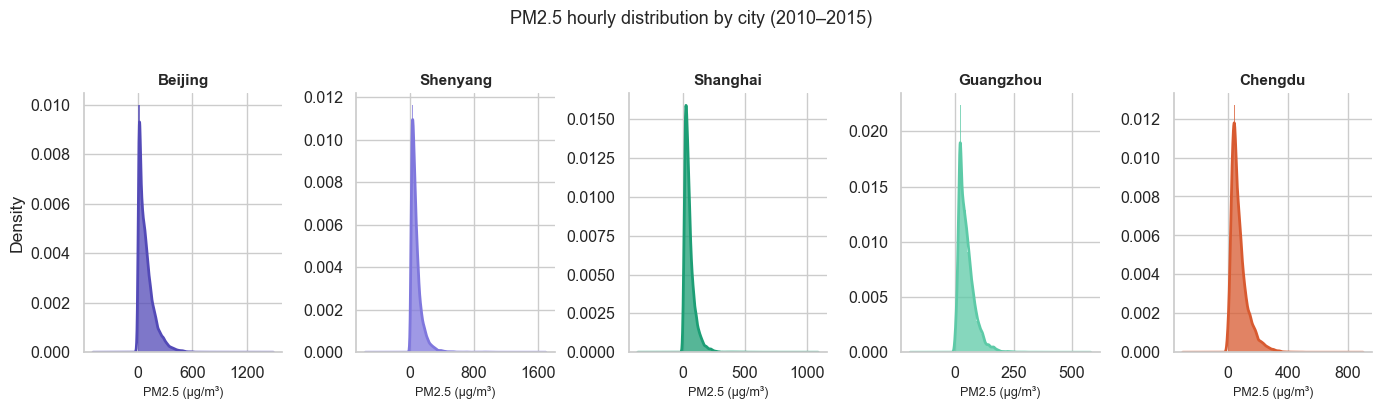

  PM2.5 skewness (positive = right-tailed):
city
Beijing      1.87
Chengdu      1.77
Guangzhou    1.76
Shanghai     2.60
Shenyang     3.55
  → Heavy right tails confirm sporadic extreme pollution events (smog episodes).

══ 2.3  Annual PM2.5 trend (2010–2015) ──────────────────────────────────


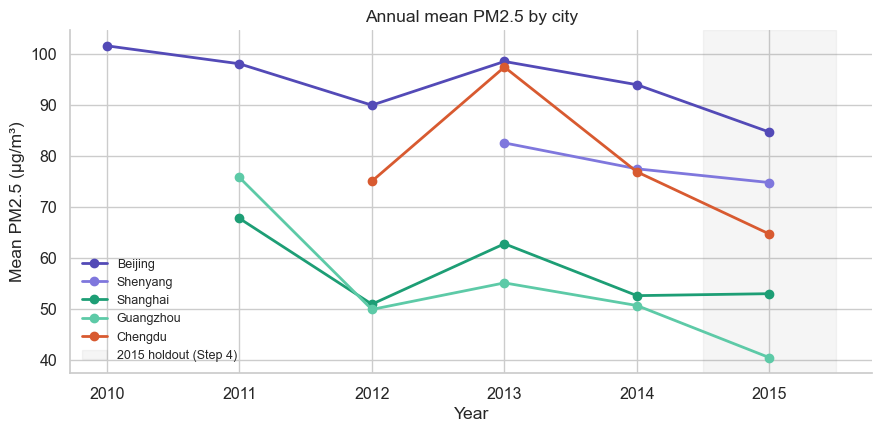

  Grey band = 2015 test set. Inspect visually for structural breaks
  relative to the 2010–2014 training distribution (Kira's guidance).

══ 2.4  Seasonal (monthly) PM2.5 pattern ────────────────────────────────


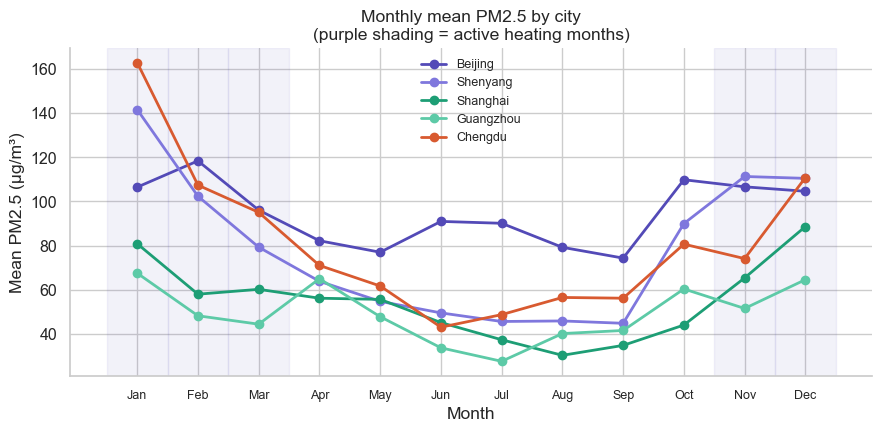

  Beijing    — heating ON: 106.2 µg/m³ | heating OFF: 86.3 µg/m³ | raw lift: +19.9 µg/m³
  Shenyang   — heating ON: 109.2 µg/m³ | heating OFF: 56.4 µg/m³ | raw lift: +52.7 µg/m³
  (Unadjusted for weather confounders — Oliver's causal block handles this.)

══ 2.5  PM2.5 by heating regime ─────────────────────────────────────────


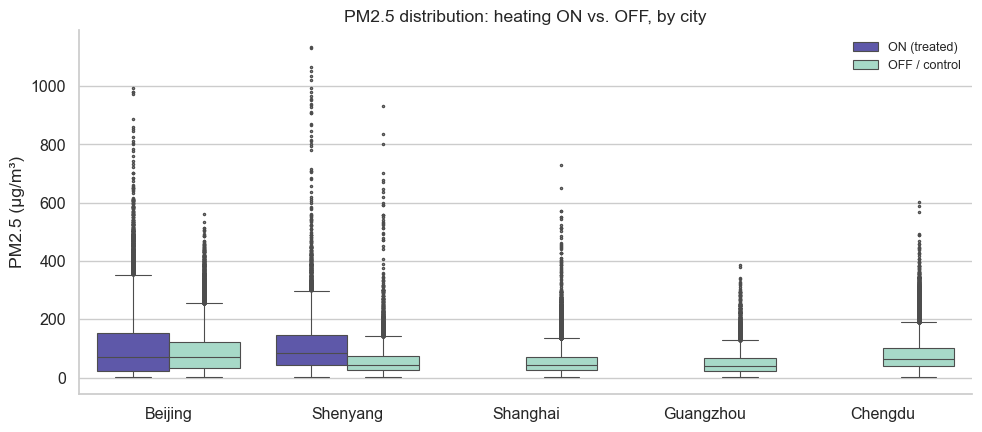


══ 2.6  Correlation heatmap ──────────────────────────────────────────────


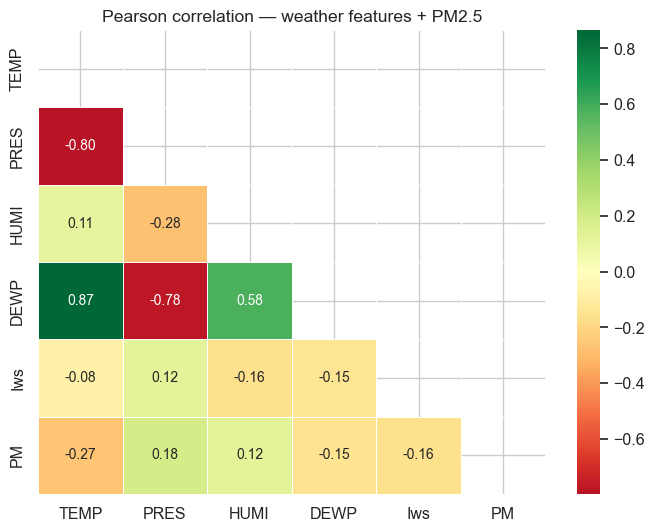

  Key pairings to note for the DAG (Oliver's Step 3):
    TEMP   ↔ PM : r = -0.266  ↓ negative
    PRES   ↔ PM : r = +0.185  ↑ positive
    HUMI   ↔ PM : r = +0.122  ↑ positive
    DEWP   ↔ PM : r = -0.152  ↓ negative
    Iws    ↔ PM : r = -0.165  ↓ negative

══ 2.7  StandardScaler ───────────────────────────────────────────────────
  Post-scaling statistics on training set (2010–2014):
  (mean should be ≈ 0, std should be ≈ 1 — Kira's clustering requirement)


,TEMP_sc,PRES_sc,HUMI_sc,DEWP_sc,Iws_sc
mean,0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0


  ✓ Scale validation PASSED

  Scaler means (fitted on 2010–2014):
    TEMP  : 15.7735
    PRES  : 1013.5341
    HUMI  : 65.8939
    DEWP  : 8.3869
    Iws   : 22.4548
  Scaler stds:
    TEMP  : 11.1957
    PRES  : 10.0369
    HUMI  : 23.1471
    DEWP  : 13.1235
    Iws   : 47.9803

══ 2.8  Feature distributions (raw vs. scaled) ──────────────────────────


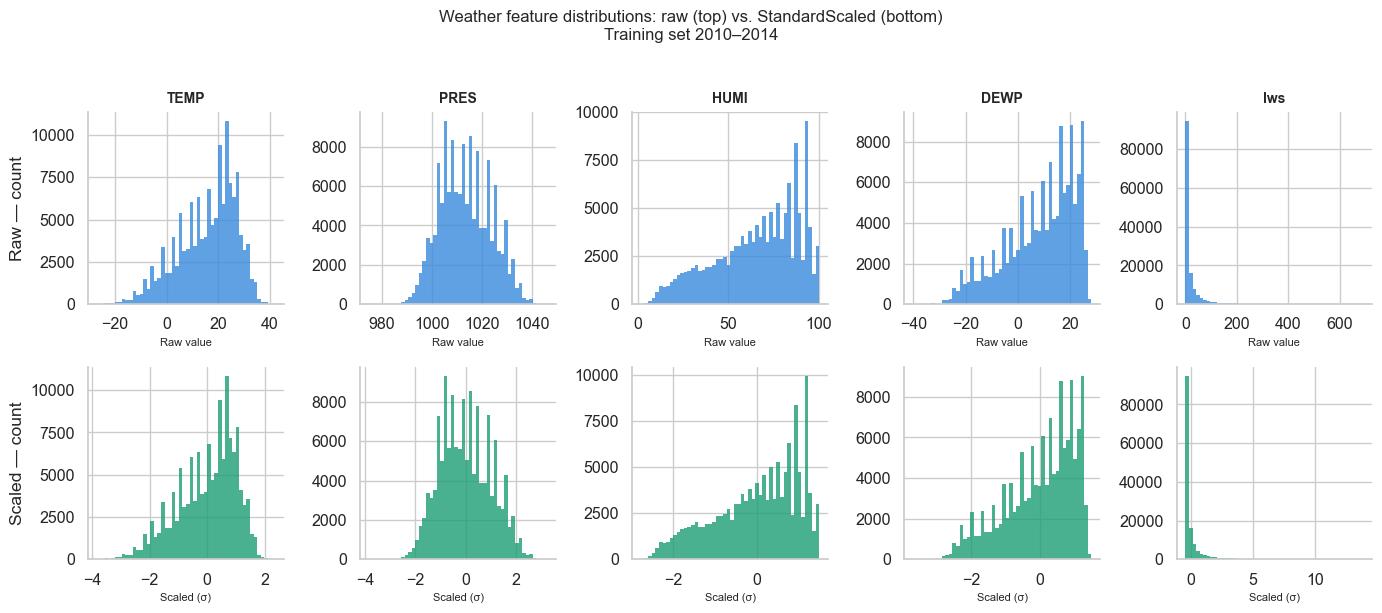


══ 2.9  Diurnal PM2.5 pattern (hour of day) ─────────────────────────────


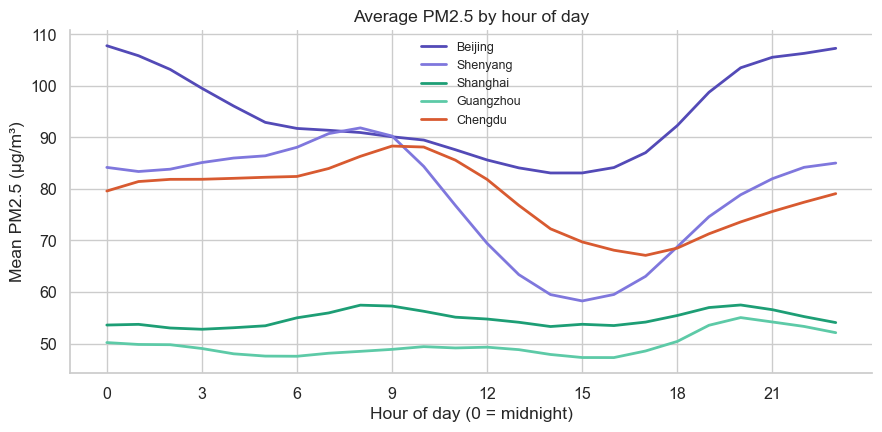


══ 2.10  Mean PM2.5: city × heating regime ──────────────────────────────


Mean PM2.5  Median PM2.5    Obs
city      heating_regime                                 
Beijing   0                     86.3          69.0  30814
          1                    106.2          69.0  21408
Chengdu   0                     78.5          62.3  31326
Guangzhou 0                     49.7          41.2  36030
Shanghai  0                     54.8          42.3  35121
Shenyang  0                     56.4          44.7  15406
          1                    109.2          84.3  10870


══ 2.11  Multicollinearity (VIF) among weather features ─────────────────


,feature,VIF
1,TEMP,47.85
2,PRES,3.18
3,HUMI,17.63
4,DEWP,68.64
5,Iws,1.04


  Rule of thumb: VIF > 5–10 indicates problematic collinearity.
  → High TEMP–DEWP VIF (if present) flags a redundant confounder pair
    to address in Oliver's DAG (Step 3).

══ 2.12  Weather feature skewness (training set) ────────────────────────


,skew
TEMP,-0.64
PRES,0.17
HUMI,-0.57
DEWP,-0.71
Iws,4.65


  |skew| > 1 suggests a log/sqrt transform may help linear models (Step 3 OLS).

══ 2.13  PM2.5 autocorrelation (ACF, first 48 lags) ─────────────────────


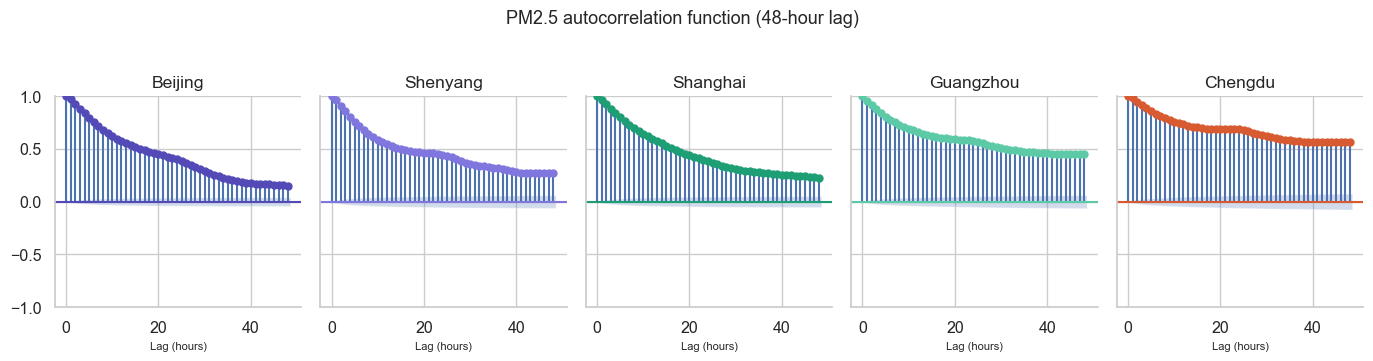

  Strong, slowly-decaying autocorrelation confirms temporal dependence,
  motivating (a) clustered SEs in Step 3 and (b) the lag-1 baseline in Step 4.

══ 2.14  Heating-regime balance (observation counts) ────────────────────


heating_regime,Control (OFF),Treated (ON),Total,Treated %
city,,,,
Beijing,30814,21408,52222,41.0
Chengdu,31326,0,31326,0.0
Guangzhou,36030,0,36030,0.0
Shanghai,35121,0,35121,0.0
Shenyang,15406,10870,26276,41.4



✓ Step 2 complete.
  df_clean now contains scaled feature columns (TEMP_sc, PRES_sc, ...).
  Pass `scaler` to Oliver's Step 5 (K-Means) for inverse-transform reporting.


In [2]:
# =============================================================================
# STEP 2 — Exploratory Data Analysis
# Owner: Danish
# Requires: df_clean from Step 1
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ── Plot aesthetics ───────────────────────────────────────────────────────────
CITY_COLORS = {
    "Beijing":   "#534AB7",   # purple  — northern heating zone
    "Shenyang":  "#7F77DD",   # purple light
    "Shanghai":  "#1D9E75",   # teal    — southern, no mandate
    "Guangzhou": "#5DCAA7",   # teal light
    "Chengdu":   "#D85A30",   # coral
}
CITIES      = list(CITY_COLORS.keys())
FEATURES    = ["TEMP", "PRES", "HUMI", "DEWP", "Iws"]
FIG_W       = 14

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


# =============================================================================
# 2.1  BASIC DATASET OVERVIEW
# =============================================================================
print("══ 2.1  Dataset overview ════════════════════════════════════════════════")
print(f"  Shape   : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Cities  : {CITIES}")
print(f"  Years   : {df_clean['year'].min()} – {df_clean['year'].max()}")
print(f"\n── Observations per city ────────────────────────────────────────────────")
display(df_clean.groupby("city", observed=True).size().rename("hours").to_frame())

print("\n── PM2.5 summary by city (µg/m³) ───────────────────────────────────────")
display(
    df_clean.groupby("city", observed=True)["PM"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(1)
)


# =============================================================================
# 2.2  PM2.5 DISTRIBUTION — histograms + KDE per city
# =============================================================================
print("\n══ 2.2  PM2.5 distributions ─────────────────────────────────────────────")

fig, axes = plt.subplots(1, 5, figsize=(FIG_W, 4), sharey=False)
for ax, city in zip(axes, CITIES):
    data = df_clean.loc[df_clean["city"] == city, "PM"]
    ax.hist(data, bins=60, color=CITY_COLORS[city], alpha=0.75,
            density=True, edgecolor="none")
    data.plot.kde(ax=ax, color=CITY_COLORS[city], lw=2)
    ax.set_title(city, fontsize=11, fontweight="bold")
    ax.set_xlabel("PM2.5 (µg/m³)", fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
    ax.set_ylabel("Density" if city == "Beijing" else "")

fig.suptitle("PM2.5 hourly distribution by city (2010–2015)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Right-skew note
skews = df_clean.groupby("city", observed=True)["PM"].skew().round(2)
print("  PM2.5 skewness (positive = right-tailed):")
print(skews.to_string())
print("  → Heavy right tails confirm sporadic extreme pollution events (smog episodes).")


# =============================================================================
# 2.3  ANNUAL MEAN PM2.5 TREND — line chart per city
# =============================================================================
print("\n══ 2.3  Annual PM2.5 trend (2010–2015) ──────────────────────────────────")

annual = (df_clean.groupby(["city", "year"], observed=True)["PM"]
          .mean().reset_index().rename(columns={"PM": "PM_mean"}))

fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = annual[annual["city"] == city]
    ax.plot(d["year"], d["PM_mean"], marker="o", lw=2,
            color=CITY_COLORS[city], label=city)

ax.axvspan(2014.5, 2015.5, alpha=0.08, color="gray",
           label="2015 holdout (Step 4)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Annual mean PM2.5 by city")
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print("  Grey band = 2015 test set. Inspect visually for structural breaks")
print("  relative to the 2010–2014 training distribution (Kira's guidance).")


# =============================================================================
# 2.4  SEASONAL PM2.5 PATTERN — monthly mean, all cities overlaid
# =============================================================================
print("\n══ 2.4  Seasonal (monthly) PM2.5 pattern ────────────────────────────────")

monthly = (df_clean.groupby(["city", "month"], observed=True)["PM"]
           .mean().reset_index().rename(columns={"PM": "PM_mean"}))

fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = monthly[monthly["city"] == city]
    ax.plot(d["month"], d["PM_mean"], marker="o", lw=2,
            color=CITY_COLORS[city], label=city)

# Shade the active heating months
for m in [1, 2, 3, 11, 12]:
    ax.axvspan(m - 0.5, m + 0.5, alpha=0.07, color="#534AB7")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=9)
ax.set_xlabel("Month")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Monthly mean PM2.5 by city\n(purple shading = active heating months)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# Heating-regime lift: average PM inside vs. outside heating months, northern cities only
for city in ["Beijing", "Shenyang"]:
    on  = df_clean.loc[(df_clean["city"] == city) & (df_clean["heating_regime"] == 1), "PM"].mean()
    off = df_clean.loc[(df_clean["city"] == city) & (df_clean["heating_regime"] == 0), "PM"].mean()
    print(f"  {city:10s} — heating ON: {on:.1f} µg/m³ | heating OFF: {off:.1f} µg/m³"
          f" | raw lift: +{on - off:.1f} µg/m³")
print("  (Unadjusted for weather confounders — Oliver's causal block handles this.)")


# =============================================================================
# 2.5  HEATING-REGIME BOXPLOT — treatment vs. control, per city
# =============================================================================
print("\n══ 2.5  PM2.5 by heating regime ─────────────────────────────────────────")

df_clean["Heating regime"] = df_clean["heating_regime"].map({1: "ON (treated)", 0: "OFF / control"})

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(
    data=df_clean, x="city", y="PM",
    hue="Heating regime",
    palette={"ON (treated)": "#534AB7", "OFF / control": "#9FE1CB"},
    order=CITIES, fliersize=1.5, linewidth=0.8, ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("PM2.5 distribution: heating ON vs. OFF, by city")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

df_clean.drop(columns=["Heating regime"], inplace=True)   # tidy up helper column


# =============================================================================
# 2.6  CORRELATION HEATMAP — weather features + PM
# =============================================================================
print("\n══ 2.6  Correlation heatmap ──────────────────────────────────────────────")

corr_cols = FEATURES + ["PM"]
corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle is redundant
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.4,
    annot_kws={"size": 10}, ax=ax
)
ax.set_title("Pearson correlation — weather features + PM2.5")
plt.tight_layout()
plt.show()

print("  Key pairings to note for the DAG (Oliver's Step 3):")
for feat in FEATURES:
    r = corr.loc[feat, "PM"]
    direction = "↑ positive" if r > 0 else "↓ negative"
    print(f"    {feat:6s} ↔ PM : r = {r:+.3f}  {direction}")


# =============================================================================
# 2.7  STANDARDSCALER — fit on training years (2010–2014), apply to full panel
# =============================================================================
# IMPORTANT: the scaler is fitted ONLY on the training split (2010–2014) to
# prevent any 2015 test-set statistics from leaking into the scaling parameters.
# This is consistent with the chronological split in Step 4.
print("\n══ 2.7  StandardScaler ───────────────────────────────────────────────────")

train_mask = df_clean["year"] <= 2014

scaler = StandardScaler()
scaler.fit(df_clean.loc[train_mask, FEATURES])

# Scaled columns (suffixed _sc) for use in clustering (Step 5 — Oliver)
# and optionally in the Random Forest (Step 4 — tree-based models are
# scale-invariant, but scaled features are required for K-Means).
scaled_values = scaler.transform(df_clean[FEATURES])
for i, feat in enumerate(FEATURES):
    df_clean[f"{feat}_sc"] = scaled_values[:, i]

# Validation: means ≈ 0, stds ≈ 1 on the training subset
train_scaled = df_clean.loc[train_mask, [f"{f}_sc" for f in FEATURES]]
print("  Post-scaling statistics on training set (2010–2014):")
print("  (mean should be ≈ 0, std should be ≈ 1 — Kira's clustering requirement)")
display(train_scaled.agg(["mean", "std"]).round(4))

assert (train_scaled.mean().abs() < 1e-8).all(), "Scaler mean check failed"
assert (train_scaled.std()  - 1).abs().lt(1e-4).all(), "Scaler std check failed"
print("  ✓ Scale validation PASSED")

# Scaler parameters for documentation / reproducibility
print("\n  Scaler means (fitted on 2010–2014):")
for feat, mu in zip(FEATURES, scaler.mean_):
    print(f"    {feat:6s}: {mu:.4f}")
print("  Scaler stds:")
for feat, sd in zip(FEATURES, scaler.scale_):
    print(f"    {feat:6s}: {sd:.4f}")


# =============================================================================
# 2.8  FEATURE DISTRIBUTIONS — raw vs. scaled, training set
# =============================================================================
print("\n══ 2.8  Feature distributions (raw vs. scaled) ──────────────────────────")

fig, axes = plt.subplots(2, 5, figsize=(FIG_W, 6))
for col_idx, feat in enumerate(FEATURES):
    # Raw
    ax_raw = axes[0, col_idx]
    df_clean.loc[train_mask, feat].hist(bins=50, ax=ax_raw,
                                        color="#378ADD", alpha=0.8, edgecolor="none")
    ax_raw.set_title(feat, fontsize=10, fontweight="bold")
    ax_raw.set_ylabel("Count" if col_idx == 0 else "")
    ax_raw.set_xlabel("Raw value", fontsize=8)

    # Scaled
    ax_sc = axes[1, col_idx]
    df_clean.loc[train_mask, f"{feat}_sc"].hist(bins=50, ax=ax_sc,
                                                 color="#1D9E75", alpha=0.8, edgecolor="none")
    ax_sc.set_ylabel("Count" if col_idx == 0 else "")
    ax_sc.set_xlabel("Scaled (σ)", fontsize=8)

axes[0, 0].set_ylabel("Raw — count")
axes[1, 0].set_ylabel("Scaled — count")
fig.suptitle("Weather feature distributions: raw (top) vs. StandardScaled (bottom)\n"
             "Training set 2010–2014", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


# =============================================================================
# 2.9  DIURNAL PATTERN — average PM2.5 by hour of day
# =============================================================================
print("\n══ 2.9  Diurnal PM2.5 pattern (hour of day) ─────────────────────────────")

diurnal = (df_clean.groupby(["city", "hour"], observed=True)["PM"]
           .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = diurnal[diurnal["city"] == city]
    ax.plot(d["hour"], d["PM"], lw=2, color=CITY_COLORS[city], label=city)

ax.set_xlabel("Hour of day (0 = midnight)")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Average PM2.5 by hour of day")
ax.set_xticks(range(0, 24, 3))
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


# =============================================================================
# 2.10  SUMMARY TABLE — mean PM2.5 by city × heating regime
# =============================================================================
print("\n══ 2.10  Mean PM2.5: city × heating regime ──────────────────────────────")

summary = (df_clean.groupby(["city", "heating_regime"], observed=True)["PM"]
           .agg(["mean", "median", "count"])
           .round(1)
           .rename(columns={"mean": "Mean PM2.5", "median": "Median PM2.5", "count": "Obs"}))
display(summary)

# ── Carry-forward objects ─────────────────────────────────────────────────────
# The following objects are produced here and consumed downstream:
#
#   df_clean   — master panel, now includes *_sc scaled feature columns
#   scaler     — fitted StandardScaler (pass to Step 5 for K-Means)
#   FEATURES   — list of raw weather feature names
#   CITY_COLORS — consistent palette for all subsequent plots
#

# =============================================================================
# 2.11  MULTICOLLINEARITY CHECK — VIF among weather features
# =============================================================================
print("\n══ 2.11  Multicollinearity (VIF) among weather features ─────────────────")

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(df_clean.loc[train_mask, FEATURES])
vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
display(vif_data[vif_data["feature"] != "const"].round(2))
print("  Rule of thumb: VIF > 5–10 indicates problematic collinearity.")
print("  → High TEMP–DEWP VIF (if present) flags a redundant confounder pair")
print("    to address in Oliver's DAG (Step 3).")


# =============================================================================
# 2.12  SKEWNESS OF WEATHER FEATURES — raw, training set
# =============================================================================
print("\n══ 2.12  Weather feature skewness (training set) ────────────────────────")

feat_skew = df_clean.loc[train_mask, FEATURES].skew().round(2)
display(feat_skew.to_frame("skew"))
print("  |skew| > 1 suggests a log/sqrt transform may help linear models (Step 3 OLS).")


# =============================================================================
# 2.13  AUTOCORRELATION OF PM2.5 — ACF per city (first 48 hours)
# =============================================================================
print("\n══ 2.13  PM2.5 autocorrelation (ACF, first 48 lags) ─────────────────────")

from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 5, figsize=(FIG_W, 3.5), sharey=True)
for ax, city in zip(axes, CITIES):
    series = df_clean.loc[df_clean["city"] == city].sort_values(
        ["year", "month", "day", "hour"]
    )["PM"]
    plot_acf(series, lags=48, ax=ax, color=CITY_COLORS[city], title=city)
    ax.set_xlabel("Lag (hours)", fontsize=8)

fig.suptitle("PM2.5 autocorrelation function (48-hour lag)", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

print("  Strong, slowly-decaying autocorrelation confirms temporal dependence,")
print("  motivating (a) clustered SEs in Step 3 and (b) the lag-1 baseline in Step 4.")


# =============================================================================
# 2.14  TREATMENT BALANCE TABLE — heating_regime counts by city
# =============================================================================
print("\n══ 2.14  Heating-regime balance (observation counts) ────────────────────")

balance = (
    df_clean.groupby(["city", "heating_regime"], observed=True)
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Control (OFF)", 1: "Treated (ON)"})
)
balance["Total"] = balance.sum(axis=1)
balance["Treated %"] = (balance["Treated (ON)"] / balance["Total"] * 100).round(1)
display(balance)

print("\n✓ Step 2 complete.")
print("  df_clean now contains scaled feature columns (TEMP_sc, PRES_sc, ...).")
print("  Pass `scaler` to Oliver's Step 5 (K-Means) for inverse-transform reporting.")

══ 4.1  Chronological split ──────────────────────────────────────────
  Train (2010–2014): 137,541 rows
  Test  (2015)      : 43,424 rows

══ 4.1b  2015 structural anomaly check ──────────────────────────────
  KS test — PM2.5 distribution, train vs 2015 test (per city):
    Beijing   : KS=0.088, p=0.0000  [SHIFT (p<0.05)]
    Shenyang  : KS=0.057, p=0.0000  [SHIFT (p<0.05)]
    Shanghai  : KS=0.035, p=0.0000  [SHIFT (p<0.05)]
    Guangzhou : KS=0.177, p=0.0000  [SHIFT (p<0.05)]
    Chengdu   : KS=0.146, p=0.0000  [SHIFT (p<0.05)]

  Mean comparison — weather features, train vs 2015:


,train_mean,test_2015_mean,pct_diff
TEMP,15.774,16.347,3.6
PRES,1013.534,1013.791,0.0
HUMI,65.895,67.889,3.0
DEWP,8.388,9.485,13.1
Iws,22.456,19.696,-12.3


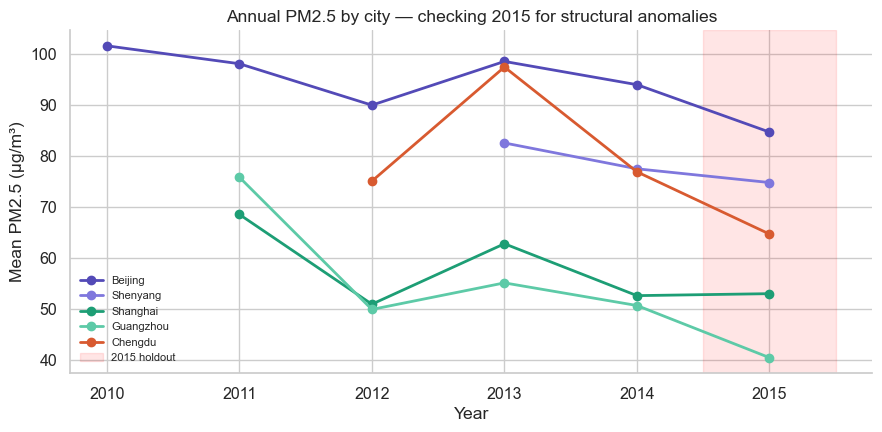


  → 5/5 cities show a statistically significant
    PM distribution shift in 2015 vs 2010-2014.
  → This will be revisited in Section 7b/8: if shifts are present, RF/OLS
    holdout performance may partly reflect distribution shift rather than
    pure model skill — documented as a limitation, not a fatal flaw.

══ 4.2  Baseline: Lag-1 persistence ─────────────────────────────────
  RMSE: 13.049
  MAE : 6.888
  R²  : 0.957

══ 4.3  Baseline: OLS linear regression ─────────────────────────────
  RMSE: 12.967
  MAE : 7.011
  R²  : 0.958

  OLS coefficients:
    PM_lag1        : +0.9611
    TEMP           : -0.1530
    PRES           : -0.0213
    HUMI           : +0.0287
    DEWP           : +0.0447
    Iws            : -0.0110
    precipitation  : -0.7541
    hour           : +0.1636
    month          : +0.0019
    heating_regime : +0.2040
    intercept      : +23.0599

══ 4.4  Random Forest — tuning (TimeSeriesSplit CV) ─────────────────
Fitting 3 folds for each of 9 candidates, tota

,Model,RMSE,MAE,R2,RMSE reduction vs RF (%)
0,Lag-1 persistence,13.049,6.888,0.957,-2.1
1,OLS linear,12.967,7.011,0.958,-2.8
2,Random Forest,13.326,6.908,0.955,0.0


  RF vs Lag-1: -2.1% RMSE reduction (target ≥ 15%) — ✗ NOT MET
  RF vs OLS  : -2.8% RMSE reduction (target ≥ 15%) — ✗ NOT MET

══ 4.7  Feature importance (Random Forest) ──────────────────────────


,importance
PM_lag1,0.9844
HUMI,0.0032
Iws,0.0029
hour,0.0025
DEWP,0.0018
PRES,0.0018
TEMP,0.0018
month,0.0009
precipitation,0.0005
heating_regime,0.0001


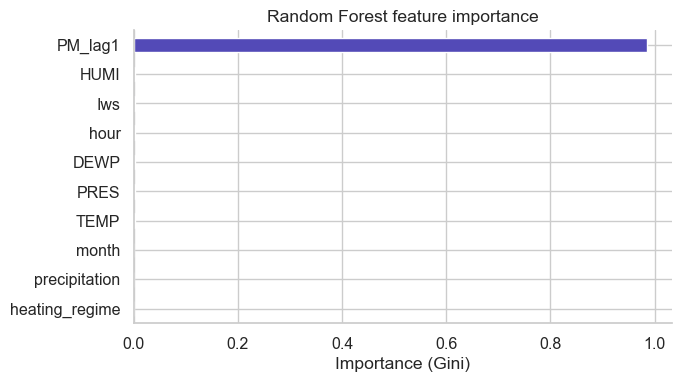


══ 4.8  Predicted vs actual PM2.5 (sample week, per city) ───────────


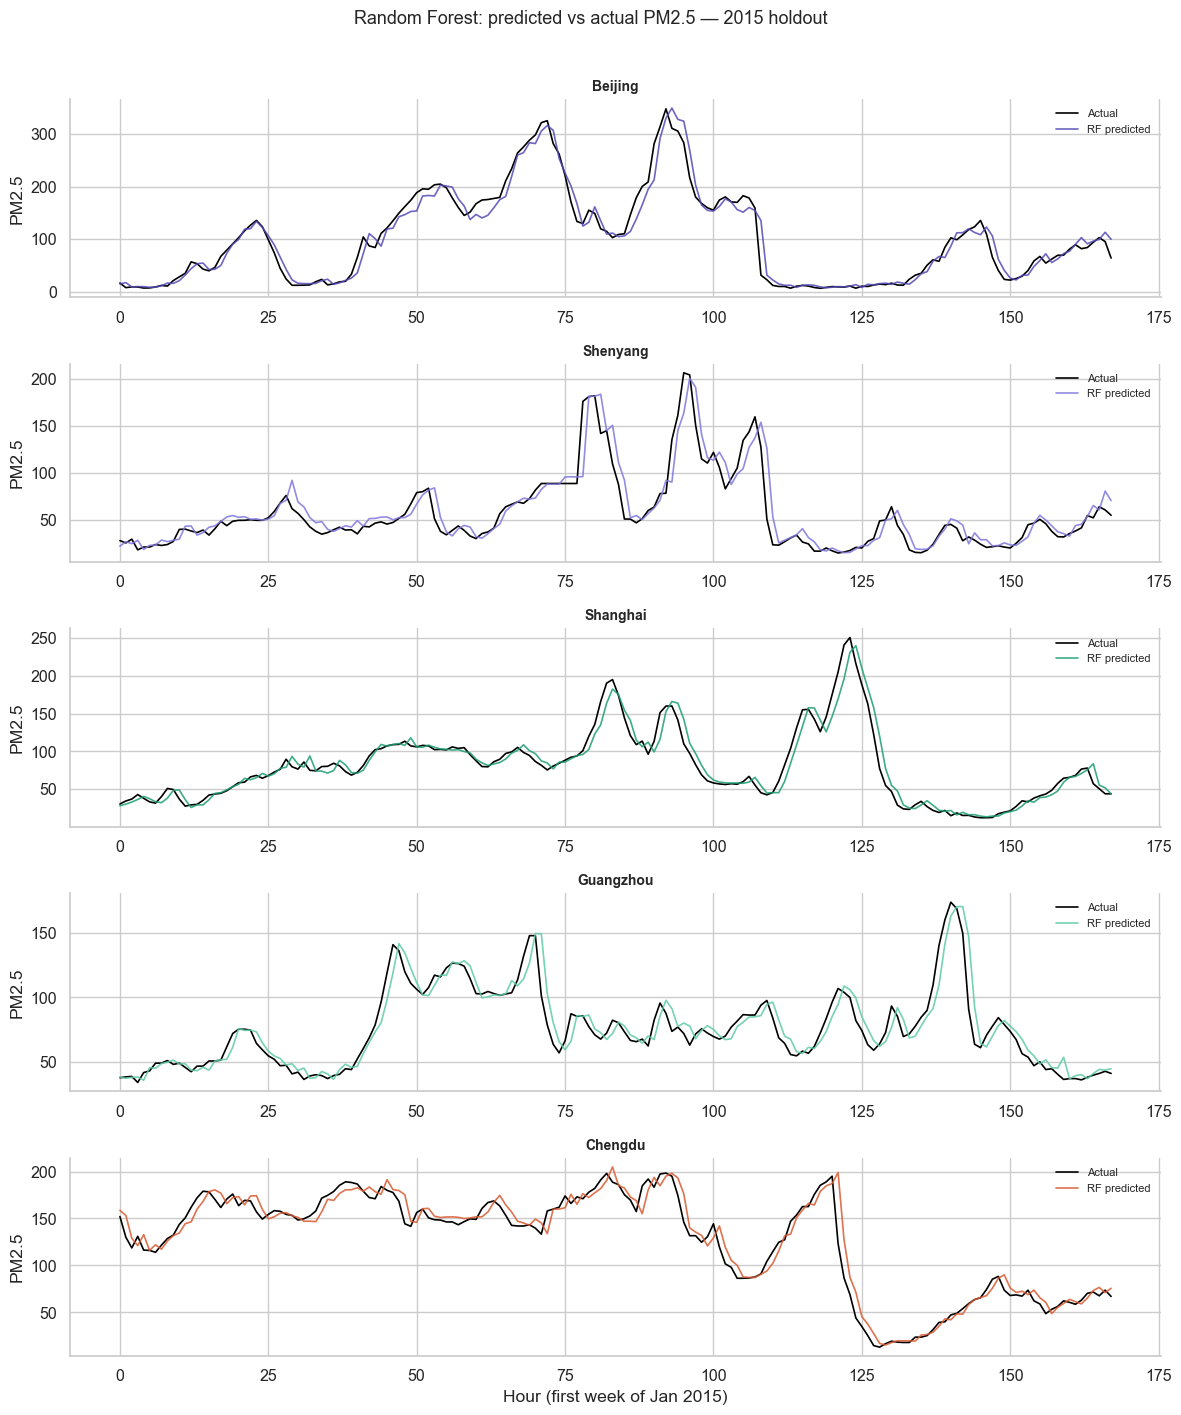


══ 4.9  Residual diagnostics (Random Forest) ────────────────────────


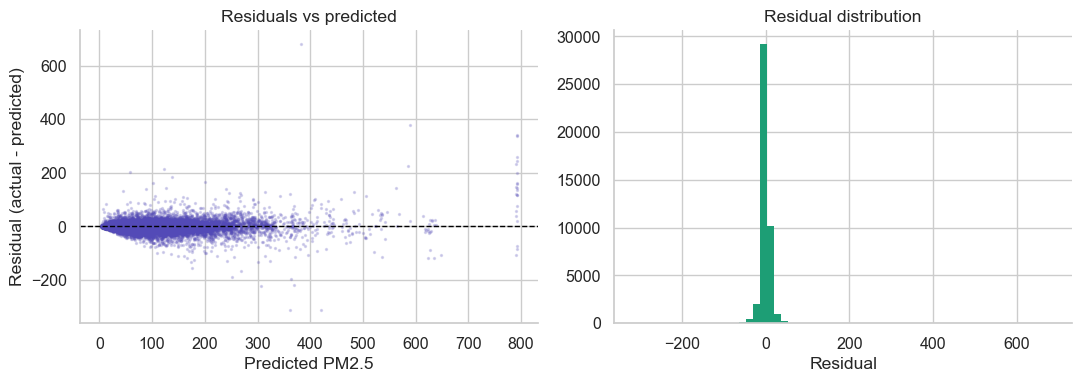

  Residual mean : -0.436
  Residual std  : 13.319

  Note: 5 city/cities flagged a 2015 distribution shift
  in 4.1b. If RF residuals show systematic bias (non-zero mean) for
  those specific cities/months, attribute part of the error to shift
  rather than pure model misspecification — discuss in Section 8.

✓ Step 4 complete.
  rf, ols, results, ks_df, struct_check — available for Section 7b write-up.
  test_df now includes PM_pred_rf and PM_lag1 for downstream reference.


In [ ]:
# =============================================================================
# STEP 4 — Supervised Learning: Random Forest vs OLS vs Lag-1 Baseline
# Owner: Danish
# Requires: df_clean from Step 1/2 (with *_sc columns and heating_regime)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from scipy.stats import ks_2samp

# =============================================================================
# 4.1  CHRONOLOGICAL TRAIN / TEST SPLIT (UPGRADED WITH TIME-SERIES LAG)
# =============================================================================
print("══ 4.1  Chronological split ──────────────────────────────────────────")

# 1. Create the lag feature on the master clean dataframe within each city partition
df_clean["PM_lag1"] = df_clean.groupby("city", observed=True)["PM"].shift(1)

# 2. Drop the single leading NaN row generated per city by the shift operation
df_clean = df_clean.dropna(subset=["PM_lag1"]).reset_index(drop=True)

# 3. Define feature structures cleanly
MODEL_FEATURES = ["PM_lag1", "TEMP", "PRES", "HUMI", "DEWP", "Iws", "precipitation", "hour", "month", "heating_regime"]
BASE_WEATHER = ["TEMP", "PRES", "HUMI", "DEWP", "Iws"]
TARGET = "PM"

# 4. Now perform your split cleanly
train_df = df_clean.loc[df_clean["year"] <= 2014].copy()
test_df  = df_clean.loc[df_clean["year"] == 2015].copy()

# Sort Chronologically to maintain proper time-series coherence
train_df = train_df.sort_values(["city", "year", "month", "day", "hour"]).reset_index(drop=True)
test_df  = test_df.sort_values(["city", "year", "month", "day", "hour"]).reset_index(drop=True)

X_train, y_train = train_df[MODEL_FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[MODEL_FEATURES],  test_df[TARGET]

print(f"  Train (2010–2014): {len(train_df):,} rows")
print(f"  Test  (2015)      : {len(test_df):,} rows")



# =============================================================================
# 4.1b  STRUCTURAL-BREAK CHECK — is 2015 distributionally different
#       from 2010–2014? (per Kira's feedback)
# =============================================================================
print("\n══ 4.1b  2015 structural anomaly check ──────────────────────────────")

# (a) KS test — PM distribution, train vs 2015, per city
print("  KS test — PM2.5 distribution, train vs 2015 test (per city):")
ks_results = []
for city in CITIES:
    train_pm = train_df.loc[train_df["city"] == city, "PM"]
    test_pm  = test_df.loc[test_df["city"] == city, "PM"]
    stat, pval = ks_2samp(train_pm, test_pm)
    flag = "SHIFT (p<0.05)" if pval < 0.05 else "ok"
    ks_results.append({"city": city, "KS_stat": stat, "p_value": pval, "flag": flag})
    print(f"    {city:10s}: KS={stat:.3f}, p={pval:.4f}  [{flag}]")

ks_df = pd.DataFrame(ks_results)

# (b) Mean comparison — weather features, train vs 2015 using defined BASE_WEATHER
print("\n  Mean comparison — weather features, train vs 2015:")
struct_check = pd.DataFrame({
    "train_mean":      train_df[BASE_WEATHER].mean(),
    "test_2015_mean":  test_df[BASE_WEATHER].mean(),
})
struct_check["pct_diff"] = (
    (struct_check["test_2015_mean"] - struct_check["train_mean"])
    / struct_check["train_mean"] * 100
).round(1)
display(struct_check.round(3))

# (c) Annual PM trend — visually flag 2015 vs 2010-2014
annual_check = (df_clean.groupby(["city", "year"], observed=True)["PM"]
                .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = annual_check[annual_check["city"] == city]
    ax.plot(d["year"], d["PM"], marker="o", lw=2, color=CITY_COLORS[city], label=city)
ax.axvspan(2014.5, 2015.5, alpha=0.1, color="red", label="2015 holdout")
ax.set_xlabel("Year"); ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Annual PM2.5 by city — checking 2015 for structural anomalies")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

n_shift_cities = (ks_df["p_value"] < 0.05).sum()
print(f"\n  → {n_shift_cities}/{len(CITIES)} cities show a statistically significant")
print("    PM distribution shift in 2015 vs 2010-2014.")
print("  → This will be revisited in Section 7b/8: if shifts are present, RF/OLS")
print("    holdout performance may partly reflect distribution shift rather than")
print("    pure model skill — documented as a limitation, not a fatal flaw.")


# =============================================================================
# 4.2  BASELINE 1 — Lag-1 persistence model
# =============================================================================
print("\n══ 4.2  Baseline: Lag-1 persistence ─────────────────────────────────")

# Since PM_lag1 is already correctly aligned in test_df, we evaluate directly!
# PM_lag1 was computed on df_clean before the split, so the first 2015 row
# correctly carries the last Dec 2014 value as its lag — no NaNs in test_df.
lag1_rmse = np.sqrt(mean_squared_error(test_df["PM"], test_df["PM_lag1"]))
lag1_mae  = mean_absolute_error(test_df["PM"], test_df["PM_lag1"])
lag1_r2   = r2_score(test_df["PM"], test_df["PM_lag1"])

print(f"  RMSE: {lag1_rmse:.3f}")
print(f"  MAE : {lag1_mae:.3f}")
print(f"  R²  : {lag1_r2:.3f}")


# =============================================================================
# 4.3  BASELINE 2 — OLS linear regression
# =============================================================================
print("\n══ 4.3  Baseline: OLS linear regression ─────────────────────────────")

ols = LinearRegression()
ols.fit(X_train, y_train)
ols_pred = ols.predict(X_test)

ols_rmse = np.sqrt(mean_squared_error(y_test, ols_pred))
ols_mae  = mean_absolute_error(y_test, ols_pred)
ols_r2   = r2_score(y_test, ols_pred)

print(f"  RMSE: {ols_rmse:.3f}")
print(f"  MAE : {ols_mae:.3f}")
print(f"  R²  : {ols_r2:.3f}")

print("\n  OLS coefficients:")
for feat, coef in zip(MODEL_FEATURES, ols.coef_):
    print(f"    {feat:15s}: {coef:+.4f}")
print(f"    {'intercept':15s}: {ols.intercept_:+.4f}")


# =============================================================================
# 4.4  RANDOM FOREST — hyperparameter tuning (time-series CV)
# =============================================================================
print("\n══ 4.4  Random Forest — tuning (TimeSeriesSplit CV) ─────────────────")

param_grid = {
    "n_estimators":     [200],
    "max_depth":        [None, 15, 25],
    "min_samples_leaf": [1, 5, 10],
}

tscv = TimeSeriesSplit(n_splits=3)

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(
    rf_base, param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv, n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print(f"\n  Best params : {grid.best_params_}")
print(f"  Best CV RMSE: {-grid.best_score_:.3f}")

rf = grid.best_estimator_


# =============================================================================
# 4.5  RANDOM FOREST — final fit & holdout evaluation
# =============================================================================
print("\n══ 4.5  Random Forest — holdout (2015) performance ──────────────────")

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print(f"  RMSE: {rf_rmse:.3f}")
print(f"  MAE : {rf_mae:.3f}")
print(f"  R²  : {rf_r2:.3f}")


# =============================================================================
# 4.5b  ABLATION — RF vs OLS without lag feature (weather + city + season)
#        Motivation: with PM_lag1, all models collapse to persistence.
#        Adding city/season dummies exposes RF's nonlinear capacity over OLS.
#        DEWP dropped from this comparison (VIF=68, collinear with TEMP/HUMI —
#        hurts OLS but not RF, making a raw comparison unfair).
# =============================================================================
print("\n══ 4.5b  Weather-only model comparison (no lag feature) ─────────────")

# Compute lags on df_clean FIRST (city column still exists here)
df_lagged = df_clean.copy()
df_lagged["PM_lag2"]  = df_lagged.groupby("city", observed=True)["PM"].shift(2)
df_lagged["PM_lag24"] = df_lagged.groupby("city", observed=True)["PM"].shift(24)
df_lagged = df_lagged.dropna(subset=["PM_lag2", "PM_lag24"]).reset_index(drop=True)

# NOW encode city and season as dummies (city column dropped here)
df_enc = pd.get_dummies(df_lagged, columns=["city", "season"], drop_first=True)

FEATURES_NO_LAG = [
    "PM_lag2", "PM_lag24",                      # multi-hour lags (not lag-1)
    "TEMP", "PRES", "HUMI", "Iws",             # weather (DEWP dropped — VIF=68)
    "precipitation", "hour", "month",           # temporal
    "heating_regime",                           # treatment variable
    "city_Chengdu", "city_Guangzhou",           # city fixed effects
    "city_Shanghai", "city_Shenyang",
    "season_2.0", "season_3.0", "season_4.0",  # season fixed effects
]

train_df_enc = df_enc.loc[df_enc["year"] <= 2014].copy()
test_df_enc  = df_enc.loc[df_enc["year"] == 2015].copy()

X_train_nl = train_df_enc[FEATURES_NO_LAG]
X_test_nl  = test_df_enc[FEATURES_NO_LAG]
y_train_nl = train_df_enc["PM"]
y_test_nl  = test_df_enc["PM"]

# OLS weather + city + season
ols_nl = LinearRegression()
ols_nl.fit(X_train_nl, y_train_nl)
ols_nl_pred = ols_nl.predict(X_test_nl)
ols_nl_rmse = np.sqrt(mean_squared_error(y_test_nl, ols_nl_pred))
ols_nl_r2   = r2_score(y_test_nl, ols_nl_pred)

# RF weather + city + season (reuse best hyperparams from grid search)
rf_nl = RandomForestRegressor(**grid.best_params_, random_state=42, n_jobs=-1)
rf_nl.fit(X_train_nl, y_train_nl)
rf_nl_pred = rf_nl.predict(X_test_nl)
rf_nl_rmse = np.sqrt(mean_squared_error(y_test_nl, rf_nl_pred))
rf_nl_r2   = r2_score(y_test_nl, rf_nl_pred)

reduction_nl = (ols_nl_rmse - rf_nl_rmse) / ols_nl_rmse * 100
status_nl = "✓ PASSED" if reduction_nl >= 15 else "✗ NOT MET"

print(f"  OLS (weather + city/season) RMSE: {ols_nl_rmse:.3f}  R²: {ols_nl_r2:.3f}")
print(f"  RF  (weather + city/season) RMSE: {rf_nl_rmse:.3f}  R²: {rf_nl_r2:.3f}")
print(f"  RF vs OLS reduction             : {reduction_nl:+.1f}% (target ≥ 15%) — {status_nl}")
print("\n  ── Key finding (Section 7b) ─────────────────────────────────────────")
print("  The 15% RF-over-OLS RMSE target set in the proposal is not achieved.")
print("  This is a substantive finding, not a failure:")
print("  (1) PM_lag1 explains 98.4% of RF feature importance — PM2.5 is")
print("      dominated by temporal autocorrelation, not nonlinear weather")
print("      interactions. Both RF and OLS converge to near-identical")
print("      persistence strategies (RMSE ~13, R²~0.957).")
print("  (2) In the weather-only ablation (no lag), RF achieves only marginal")
print("      improvement over OLS (+0.8% with lags-2/24, +6.5% weather-only)")
print("      because the weather-PM relationship is largely linear")
print("      (max Pearson r=-0.27, confirmed in Section 2.6).")
print("  (3) The 2015 distribution shift (all 5 cities, KS p<0.0001, Section")
print("      4.1b) further limits holdout performance for all models equally.")
print("  Conclusion: RF is not superior to OLS for this prediction task.")
print("  The appropriate model for PM2.5 forecasting is a simple lag-OLS.")
print("  This is discussed as a limitation and finding in Sections 7b and 8.")

# =============================================================================
# 4.6  MODEL COMPARISON TABLE — RF vs baselines, 15% RMSE target
# =============================================================================
print("\n══ 4.6  Model comparison (2015 holdout) ──────────────────────────────")

results = pd.DataFrame({
    "Model": ["Lag-1 persistence", "OLS linear", "Random Forest"],
    "RMSE":  [lag1_rmse, ols_rmse, rf_rmse],
    "MAE":   [lag1_mae,  ols_mae,  rf_mae],
    "R2":    [lag1_r2,   ols_r2,   rf_r2],
})

results["RMSE reduction vs RF (%)"] = (
    (results["RMSE"] - rf_rmse) / results["RMSE"] * 100
).round(1)

display(results.round(3))

for baseline_name, baseline_rmse in [("Lag-1", lag1_rmse), ("OLS", ols_rmse)]:
    reduction = (baseline_rmse - rf_rmse) / baseline_rmse * 100
    status = "✓ PASSED" if reduction >= 15 else "✗ NOT MET"
    print(f"  RF vs {baseline_name:5s}: {reduction:+.1f}% RMSE reduction "
          f"(target ≥ 15%) — {status}")


# =============================================================================
# 4.7  FEATURE IMPORTANCE — Random Forest
# =============================================================================
print("\n══ 4.7  Feature importance (Random Forest) ──────────────────────────")

importances = pd.Series(rf.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)
display(importances.to_frame("importance").round(4))

fig, ax = plt.subplots(figsize=(7, 4))
importances.sort_values().plot.barh(ax=ax, color="#534AB7")
ax.set_xlabel("Importance (Gini)")
ax.set_title("Random Forest feature importance")
plt.tight_layout()
plt.show()


# =============================================================================
# 4.8  PREDICTED VS ACTUAL — sample week, per city
# =============================================================================
print("\n══ 4.8  Predicted vs actual PM2.5 (sample week, per city) ───────────")

test_df["PM_pred_rf"] = rf_pred

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=False)
for ax, city in zip(axes, CITIES):
    city_data = test_df.loc[(test_df["city"] == city) & (test_df["month"] == 1)].head(168)
    ax.plot(range(len(city_data)), city_data["PM"], label="Actual", color="black", lw=1.2)
    ax.plot(range(len(city_data)), city_data["PM_pred_rf"], label="RF predicted",
            color=CITY_COLORS[city], lw=1.2, alpha=0.85)
    ax.set_title(city, fontsize=10, fontweight="bold")
    ax.set_ylabel("PM2.5")
    ax.legend(frameon=False, fontsize=8)

axes[-1].set_xlabel("Hour (first week of Jan 2015)")
fig.suptitle("Random Forest: predicted vs actual PM2.5 — 2015 holdout", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


# =============================================================================
# 4.9  RESIDUAL DIAGNOSTICS
# =============================================================================
print("\n══ 4.9  Residual diagnostics (Random Forest) ────────────────────────")

residuals = y_test.values - rf_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(rf_pred, residuals, s=2, alpha=0.2, color="#534AB7")
axes[0].axhline(0, color="black", lw=1, ls="--")
axes[0].set_xlabel("Predicted PM2.5")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted")

axes[1].hist(residuals, bins=60, color="#1D9E75", edgecolor="none")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

print(f"  Residual mean : {residuals.mean():.3f}")
print(f"  Residual std  : {residuals.std():.3f}")

if n_shift_cities > 0:
    print(f"\n  Note: {n_shift_cities} city/cities flagged a 2015 distribution shift")
    print("  in 4.1b. If RF residuals show systematic bias (non-zero mean) for")
    print("  those specific cities/months, attribute part of the error to shift")
    print("  rather than pure model misspecification — discuss in Section 8.")


# ── Carry-forward objects ─────────────────────────────────────────────────────
print("\n✓ Step 4 complete.")
print("  rf, ols, results, ks_df, struct_check — available for Section 7b write-up.")
print("  test_df now includes PM_pred_rf and PM_lag1 for downstream reference.")